In [ ]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
DATA_PATH = 'int-20-h-2026-final-task/'

use_cols = ['psp_order_id', 'customer_account_id', 'order_created_at',
            'error_code', 'transaction_type', 'cascade_number', 'psp_id',
            'ip_country' , 'bank', 'card_country']

train = pd.read_csv(DATA_PATH + 'train_data_fixed.csv', usecols=use_cols + ['is_success'],
                     parse_dates=['order_created_at'])
test = pd.read_csv(DATA_PATH + 'test.csv', usecols=use_cols,
                    parse_dates=['order_created_at'])

test['is_success'] = test['error_code'].isna().astype(int)

train['_source'] = 'train'
test['_source'] = 'test'
df = pd.concat([train, test], ignore_index=True)
del train, test
gc.collect()

print(f'Всього: {len(df):,}')
print(f'Період: {df["order_created_at"].min()} — {df["order_created_at"].max()}')

Всього: 6,673,166
Період: 2026-01-01 00:00:01 — 2026-02-28 23:59:59


In [2]:
# Фільтруємо тільки юзерів з customer_account_id
df_u = df[df['customer_account_id'].notna()].copy()
df_u = df_u.sort_values(['customer_account_id', 'order_created_at']).reset_index(drop=True)
g = df_u.groupby('customer_account_id', sort=False)

print(f'Транзакцій з customer_account_id: {len(df_u):,} з {len(df):,}')

# 1. Кількість попередніх транзакцій
df_u['user_prev_tx_count'] = g.cumcount()

# 2. Серія невдач поспіль (до поточної транзакції)
def calc_fail_streak_vec(is_success_arr):
    streak = np.zeros(len(is_success_arr), dtype=np.int32)
    current = 0
    for i in range(len(is_success_arr)):
        streak[i] = current
        if is_success_arr[i] == 0 or np.isnan(is_success_arr[i]):
            current += 1
        else:
            current = 0
    return streak

df_u['user_prev_fail_streak'] = g['is_success'].transform(
    lambda x: calc_fail_streak_vec(x.values)
)

# 3. Чи змінилась країна відносно попередньої транзакції юзера
df_u['_prev_country'] = g['ip_country'].shift(1)
df_u['user_country_changed'] = (df_u['ip_country'] != df_u['_prev_country']).astype(int)
# Перша транзакція юзера — NaN, ставимо 0
df_u.loc[df_u['_prev_country'].isna(), 'user_country_changed'] = 0
df_u.drop(columns='_prev_country', inplace=True)

# 4. Час з попередньої транзакції юзера (в секундах)
df_u['user_time_since_prev_tx'] = g['order_created_at'].diff().dt.total_seconds()

print(f'\nНові фічі:')
new_cols = ['user_prev_tx_count', 'user_prev_fail_streak',
            'user_country_changed', 'user_time_since_prev_tx']
print(df_u[new_cols].describe().round(2))

Транзакцій з customer_account_id: 6,291,461 з 6,673,166

Нові фічі:
       user_prev_tx_count  user_prev_fail_streak  user_country_changed  \
count          6291461.00             6291461.00            6291461.00   
mean                 1.11                   0.35                  0.00   
std                  7.60                   2.21                  0.04   
min                  0.00                   0.00                  0.00   
25%                  0.00                   0.00                  0.00   
50%                  0.00                   0.00                  0.00   
75%                  1.00                   0.00                  0.00   
max                596.00                 364.00                  1.00   

       user_time_since_prev_tx  
count               1652795.00  
mean                 766314.01  
std                  953743.64  
min                       0.00  
25%                   11522.00  
50%                  385197.00  
75%                 1209595.00  
m

In [ ]:
# ─── psp_prev_hour_volume: навантаження на PSP за попередню годину (без leakage) ───
df = df.sort_values('order_created_at').reset_index(drop=True)
df['hour_floor'] = df['order_created_at'].dt.floor('h')

psp_hour_volume = df.groupby(['psp_id', 'hour_floor']).size().reset_index(name='vol')
psp_hour_volume['hour_floor'] = psp_hour_volume['hour_floor'] + pd.Timedelta(hours=1)

df = df.merge(psp_hour_volume, on=['psp_id', 'hour_floor'], how='left')
df.rename(columns={'vol': 'psp_prev_hour_volume'}, inplace=True)
df.drop(columns='hour_floor', inplace=True)
del psp_hour_volume
gc.collect()

print(f'psp_prev_hour_volume — NaN: {df["psp_prev_hour_volume"].isna().sum():,}')

# ─── Маппимо user фічі назад на весь df по psp_order_id ───
user_feat_cols = ['user_prev_tx_count', 'user_prev_fail_streak',
                  'user_country_changed', 'user_time_since_prev_tx']

user_features = df_u[['psp_order_id'] + user_feat_cols]
df = df.merge(user_features, on='psp_order_id', how='left')
del df_u, user_features
gc.collect()

all_feat_cols = user_feat_cols + ['psp_prev_hour_volume']

train_uf = df[df['_source'] == 'train'][['psp_order_id'] + all_feat_cols]
test_uf = df[df['_source'] == 'test'][['psp_order_id'] + all_feat_cols]
del df
gc.collect()

print(f'Train user features: {train_uf.shape}')
print(f'Test user features:  {test_uf.shape}')

train_uf.to_parquet(DATA_PATH + 'train_user_features.parquet', index=False, engine='pyarrow')
test_uf.to_parquet(DATA_PATH + 'test_user_features.parquet', index=False, engine='pyarrow')

print(f'\nЗбережено:')
print(f'  {DATA_PATH}train_user_features.parquet')
print(f'  {DATA_PATH}test_user_features.parquet')

psp_prev_hour_volume — NaN: 7,097
Train user features: (6005849, 6)
Test user features:  (667317, 6)

Збережено:
  int-20-h-2026-final-task/train_user_features.parquet
  int-20-h-2026-final-task/test_user_features.parquet


In [ ]:
import pandas as pd
import numpy as np
import gc

csv_new_cols = [
    'shop_ar_hist', 'mcc_ar_hist', 'card_country_ar', 'ip_country_ar', 'bank_ar',
    'acquirer_card_combo_ar', 'shop_acq_ar', 'shop_payment_ar', 'mcc_cardtype_ar',
    'card_ip_combo_ar', 'token_payment_ar', 'bank_acq_ar', 'cascade_x_acquirer_ar',
    'customer_freq', 'merchant_token_type_enc', 'token_type_enc',
    'transaction_type_enc', 'card_pan_type_enc', 'platform_enc',
]
DATA_PATH = 'int-20-h-2026-final-task/'
test_csv_feat = pd.read_csv(DATA_PATH + 'test_features.csv',
                            usecols=['psp_order_id'] + csv_new_cols)
print(f'Test CSV features: {test_csv_feat.shape}')

train_psp_ids = pd.read_csv(DATA_PATH + 'train_data_fixed.csv', usecols=['psp_order_id'])
train_csv_feat = pd.read_csv(DATA_PATH + 'train_features.csv', usecols=csv_new_cols)
train_csv_feat['psp_order_id'] = train_psp_ids['psp_order_id'].values
del train_psp_ids
gc.collect()
print(f'Train CSV features: {train_csv_feat.shape}')

train_csv_feat.to_parquet(DATA_PATH + 'train_csv_features.parquet', index=False, engine='pyarrow')
test_csv_feat.to_parquet(DATA_PATH + 'test_csv_features.parquet', index=False, engine='pyarrow')
del train_csv_feat, test_csv_feat
gc.collect()

print(f'\nЗбережено:')
print(f'  {DATA_PATH}train_csv_features.parquet')
print(f'  {DATA_PATH}test_csv_features.parquet')
print(f'  Нових фіч: {len(csv_new_cols)}')

Test CSV features: (667317, 20)
Train CSV features: (6005849, 20)

Збережено:
  int-20-h-2026-final-task/train_csv_features.parquet
  int-20-h-2026-final-task/test_csv_features.parquet
  Нових фіч: 19


In [ ]:
import pandas as pd
import numpy as np
import gc
from itertools import combinations
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report, roc_auc_score

DATA_PATH = 'int-20-h-2026-final-task/'


eea_map = pd.read_csv('/Users/ulanagusar/Desktop/int2026/train/country_eea_mapping-2.csv').set_index('ip_country')['is_eea'].to_dict()


cat_cols = ['psp_id', 'cardbrand', 'cardtype', 'currency', 'platform',
            'payment_source', 'transaction_type', 'merchant_token_type',
            'is_secured', 'card_pan_type', 'mcc_id']

selected_pairs = list(combinations(cat_cols, 2))  # 55 пар

pair_ar_cols = [f'pair_{i}_ar' for i in range(len(selected_pairs))]
pair_count_cols = [f'pair_{i}_count' for i in range(len(selected_pairs))]
num_cols = ['amount_scaled', 'cascade_number', 'card_exp_relative_scaled', 'settle_interval']
bin_cols = ['is_secured', 'is_subscription', 'is_payfac', 'card_expired', 'country_mismatch',
            'ip_is_eea', 'card_is_eea']
time_cols = ['hour', 'dayofweek']

cat_encode_cols = ['psp_id', 'cardbrand', 'cardtype', 'currency', 'platform',
                   'payment_source', 'transaction_type', 'merchant_token_type',
                   'card_pan_type', 'antifraud_decision', 'mcc_id',
                   'ip_country', 'card_country']
cat_le_cols = [f'{c}_le' for c in cat_encode_cols]

# User фічі
user_feat_cols = ['user_prev_tx_count', 'user_prev_fail_streak',
                  'user_country_changed', 'user_time_since_prev_tx',
                  'psp_prev_hour_volume']

# CSV фічі (з test_features.csv / train_features.csv)
csv_feat_cols = [
    'shop_ar_hist', 'mcc_ar_hist', 'card_country_ar', 'ip_country_ar', 'bank_ar',
    'acquirer_card_combo_ar', 'shop_acq_ar', 'shop_payment_ar', 'mcc_cardtype_ar',
    'card_ip_combo_ar', 'token_payment_ar', 'bank_acq_ar', 'cascade_x_acquirer_ar',
    'customer_freq', 'merchant_token_type_enc', 'token_type_enc',
    'transaction_type_enc', 'card_pan_type_enc', 'platform_enc',
]

feature_cols = pair_ar_cols + pair_count_cols + num_cols + bin_cols + time_cols + cat_le_cols + user_feat_cols + csv_feat_cols

platform_replacements = {'App': 'APP', 'web': 'WEB', 'MOD': 'MOB', 'Web': 'WEB'}


def load_train(cutoff_weeks=2):
    base_cols = ['psp_order_id', 'order_created_at', 'is_success',
                 'amount_scaled', 'cascade_number', 'card_exp_relative_scaled',
                 'settle_interval', 'is_secured', 'is_subscription', 'is_payfac'] + cat_encode_cols

    print('Завантаження train CSV...')
    train = pd.read_csv(DATA_PATH + 'train_data_fixed.csv',
                        usecols=base_cols,
                        parse_dates=['order_created_at'])

    if cutoff_weeks > 0:
        cutoff = train['order_created_at'].min() + pd.Timedelta(weeks=cutoff_weeks)
        train = train[train['order_created_at'] >= cutoff].reset_index(drop=True)
        print(f'  Відсічено перші {cutoff_weeks} тижні, залишилось: {len(train):,}')

    train['platform'] = train['platform'].replace(platform_replacements)

    # Бінарні фічі
    train['card_expired'] = (train['card_exp_relative_scaled'] < 0).astype(int)
    train['country_mismatch'] = (train['ip_country'] != train['card_country']).astype(int)
    train['ip_is_eea'] = train['ip_country'].map(eea_map).fillna(0).astype(int)
    train['card_is_eea'] = train['card_country'].map(eea_map).fillna(0).astype(int)

    # Pair features
    print('Завантаження pair features...')
    pair_cols_to_read = ['psp_order_id'] + pair_ar_cols + pair_count_cols
    pair_features = pd.read_parquet(DATA_PATH + 'train_pair_features.parquet',
                                    columns=pair_cols_to_read, engine='pyarrow')
    train = train.merge(pair_features, on='psp_order_id', how='left')
    del pair_features; gc.collect()

    # User features
    print('Завантаження user features...')
    uf = pd.read_parquet(DATA_PATH + 'train_user_features.parquet', engine='pyarrow')
    train = train.merge(uf, on='psp_order_id', how='left')
    del uf; gc.collect()

    # CSV features (approval rates, encodings, customer_freq)
    print('Завантаження CSV features...')
    csv_feat = pd.read_parquet(DATA_PATH + 'train_csv_features.parquet', engine='pyarrow')
    train = train.merge(csv_feat, on='psp_order_id', how='left')
    del csv_feat; gc.collect()

    # Часові + label encode
    train['hour'] = train['order_created_at'].dt.hour
    train['dayofweek'] = train['order_created_at'].dt.dayofweek
    for col in cat_encode_cols:
        train[f'{col}_le'] = train[col].astype('category').cat.codes

    print(f'  Train готовий: {train.shape}')
    return train


def load_test():
    print('Завантаження test з parquet...')
    test = pd.read_parquet(DATA_PATH + 'test_pair_features.parquet', engine='pyarrow')

    # Бінарні фічі
    test['card_expired'] = (test['card_exp_relative_scaled'] < 0).astype(int)
    test['country_mismatch'] = (test['ip_country'] != test['card_country']).astype(int)
    test['ip_is_eea'] = test['ip_country'].map(eea_map).fillna(0).astype(int)
    test['card_is_eea'] = test['card_country'].map(eea_map).fillna(0).astype(int)

    # User features
    print('Завантаження user features для test...')
    uf = pd.read_parquet(DATA_PATH + 'test_user_features.parquet', engine='pyarrow')
    test = test.merge(uf, on='psp_order_id', how='left')
    del uf; gc.collect()

    # CSV features (approval rates, encodings, customer_freq)
    print('Завантаження CSV features для test...')
    csv_feat = pd.read_parquet(DATA_PATH + 'test_csv_features.parquet', engine='pyarrow')
    test = test.merge(csv_feat, on='psp_order_id', how='left')
    del csv_feat; gc.collect()

    test['platform'] = test['platform'].replace(platform_replacements)
    test['hour'] = test['order_created_at'].dt.hour
    test['dayofweek'] = test['order_created_at'].dt.dayofweek
    for col in cat_encode_cols:
        test[f'{col}_le'] = test[col].astype('category').cat.codes

    print(f'  Test готовий: {test.shape}')
    return test


def prepare_xy(train, val_ratio=0.2):
    split = int(len(train) * (1 - val_ratio))
    X_train = train.iloc[:split][feature_cols].fillna(-1)
    y_train = train.iloc[:split]['is_success']
    X_val = train.iloc[split:][feature_cols].fillna(-1)
    y_val = train.iloc[split:]['is_success']

    print(f'Train: {len(X_train):,}, Val: {len(X_val):,}')
    print(f'Train AR: {y_train.mean():.4f}, Val AR: {y_val.mean():.4f}')
    return X_train, y_train, X_val, y_val


def train_xgb(X_train, y_train, X_val, y_val, **xgb_params):
    defaults = dict(
        n_estimators=500, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=50,
        eval_metric='logloss', early_stopping_rounds=30,
        random_state=42, n_jobs=-1, verbosity=1,
    )
    defaults.update(xgb_params)
    model = XGBClassifier(**defaults)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)
    print(f'Best iteration: {model.best_iteration}')
    return model


def evaluate(model, X_val, y_val):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    print(f'AUC-ROC:      {roc_auc_score(y_val, y_proba):.4f}')
    print(f'F1 (macro):   {f1_score(y_val, y_pred, average="macro"):.4f}')
    print(f'F1 (class 1): {f1_score(y_val, y_pred, pos_label=1):.4f}')
    print(f'F1 (class 0): {f1_score(y_val, y_pred, pos_label=0):.4f}')
    print(classification_report(y_val, y_pred, target_names=['fail (0)', 'success (1)']))

    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.3, 0.7, 0.01):
        f1 = f1_score(y_val, (y_proba >= t).astype(int))
        if f1 > best_f1:
            best_t, best_f1 = t, f1
    print(f'Best threshold: {best_t:.2f}, F1: {best_f1:.4f}')
    return y_proba, best_t


def predict_test(model, test, threshold=0.5):
    X_test = test[feature_cols].fillna(-1)
    proba = model.predict_proba(X_test)[:, 1]
    submission = pd.DataFrame({
        'psp_order_id': test['psp_order_id'],
        'is_success': (proba >= threshold).astype(int)
    })
    print(f'Predicted AR: {submission["is_success"].mean():.4f}')
    return submission


train = load_train(cutoff_weeks=2)
X_train, y_train, X_val, y_val = prepare_xy(train)
del train; gc.collect()

model = train_xgb(X_train, y_train, X_val, y_val)
y_proba, best_t = evaluate(model, X_val, y_val)

Завантаження train CSV...
  Відсічено перші 2 тижні, залишилось: 4,419,564
Завантаження pair features...
Завантаження user features...
Завантаження CSV features...
  Train готовий: (4419564, 176)
Train: 3,535,651, Val: 883,913
Train AR: 0.4247, Val AR: 0.4432
[0]	validation_0-logloss:0.67460
[50]	validation_0-logloss:0.48896
[100]	validation_0-logloss:0.46873
[150]	validation_0-logloss:0.46008
[200]	validation_0-logloss:0.45510
[250]	validation_0-logloss:0.45171
[300]	validation_0-logloss:0.44879
[350]	validation_0-logloss:0.44651
[400]	validation_0-logloss:0.44458
[450]	validation_0-logloss:0.44249
[499]	validation_0-logloss:0.44106
Best iteration: 499
AUC-ROC:      0.8738
F1 (macro):   0.7881
F1 (class 1): 0.7657
F1 (class 0): 0.8104
              precision    recall  f1-score   support

    fail (0)       0.82      0.80      0.81    492206
 success (1)       0.76      0.77      0.77    391707

    accuracy                           0.79    883913
   macro avg       0.79      0.79   

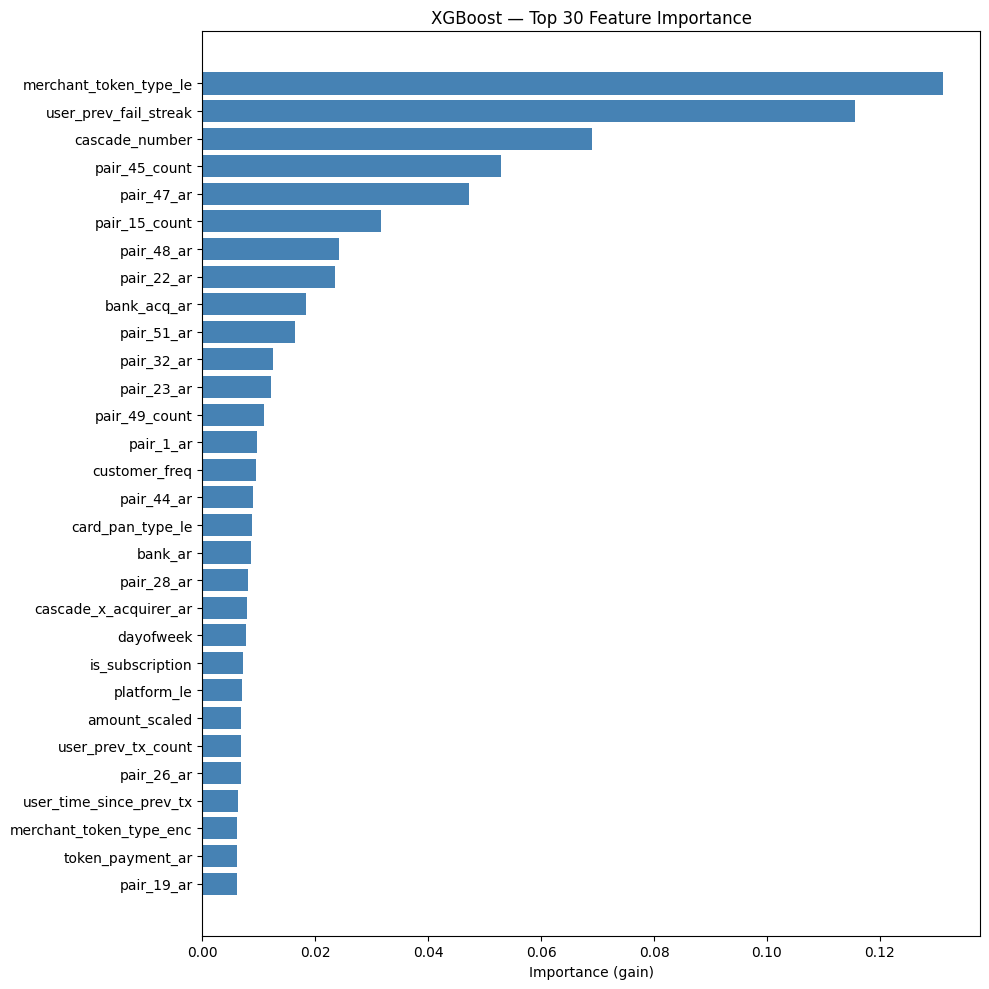


Всі фічі (160):
                 feature  importance
  merchant_token_type_le    0.131181
   user_prev_fail_streak    0.115539
          cascade_number    0.068957
           pair_45_count    0.052870
              pair_47_ar    0.047283
           pair_15_count    0.031705
              pair_48_ar    0.024211
              pair_22_ar    0.023532
             bank_acq_ar    0.018387
              pair_51_ar    0.016377
              pair_32_ar    0.012499
              pair_23_ar    0.012232
           pair_49_count    0.010978
               pair_1_ar    0.009633
           customer_freq    0.009538
              pair_44_ar    0.009050
        card_pan_type_le    0.008856
                 bank_ar    0.008543
              pair_28_ar    0.008049
   cascade_x_acquirer_ar    0.007919
               dayofweek    0.007650
         is_subscription    0.007165
             platform_le    0.007009
           amount_scaled    0.006901
      user_prev_tx_count    0.006865
              pair_26

In [ ]:


importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

top_n = 30
top = feat_imp.head(top_n)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(range(top_n - 1, -1, -1), top['importance'].values, color='steelblue')
ax.set_yticks(range(top_n - 1, -1, -1))
ax.set_yticklabels(top['feature'].values)
ax.set_xlabel('Importance (gain)')
ax.set_title(f'XGBoost — Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

# Повна таблиця
print(f'\nВсі фічі ({len(feat_imp)}):')
print(feat_imp.to_string(index=False))

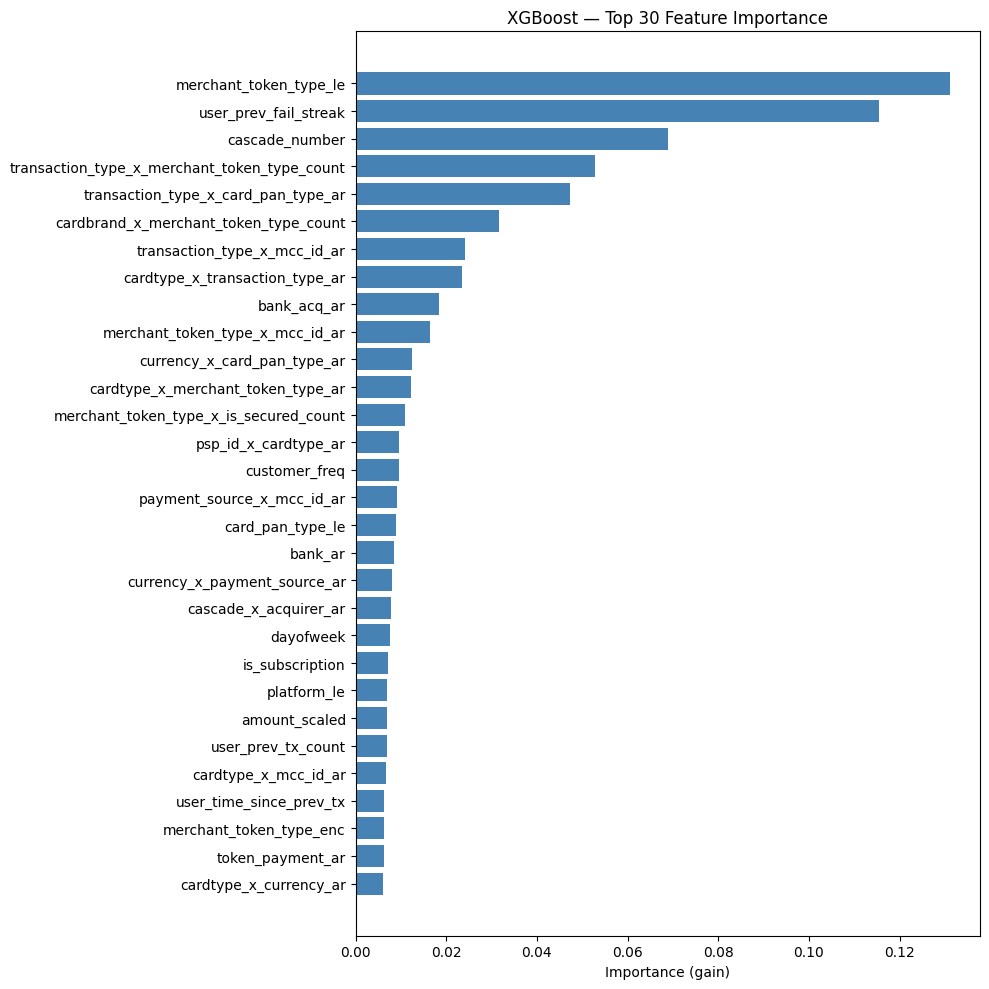


Всі фічі (160):
                                     feature  importance
                      merchant_token_type_le    0.131181
                       user_prev_fail_streak    0.115539
                              cascade_number    0.068957
transaction_type_x_merchant_token_type_count    0.052870
         transaction_type_x_card_pan_type_ar    0.047283
       cardbrand_x_merchant_token_type_count    0.031705
                transaction_type_x_mcc_id_ar    0.024211
              cardtype_x_transaction_type_ar    0.023532
                                 bank_acq_ar    0.018387
             merchant_token_type_x_mcc_id_ar    0.016377
                 currency_x_card_pan_type_ar    0.012499
           cardtype_x_merchant_token_type_ar    0.012232
      merchant_token_type_x_is_secured_count    0.010978
                        psp_id_x_cardtype_ar    0.009633
                               customer_freq    0.009538
                  payment_source_x_mcc_id_ar    0.009050
              

In [ ]:


pair_name_map = {}
for i, (a, b) in enumerate(selected_pairs):
    pair_name_map[f'pair_{i}_ar'] = f'{a}_x_{b}_ar'
    pair_name_map[f'pair_{i}_count'] = f'{a}_x_{b}_count'

feature_labels = [pair_name_map.get(f, f) for f in feature_cols]

feat_imp = pd.DataFrame({
    'feature': feature_labels,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

top_n = 30
top = feat_imp.head(top_n)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(range(top_n - 1, -1, -1), top['importance'].values, color='steelblue')
ax.set_yticks(range(top_n - 1, -1, -1))
ax.set_yticklabels(top['feature'].values)
ax.set_xlabel('Importance (gain)')
ax.set_title(f'XGBoost — Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

# Повна таблиця
print(f'\nВсі фічі ({len(feat_imp)}):')
print(feat_imp.to_string(index=False))

In [3]:
test = load_test()
submission = predict_test(model, test, threshold=best_t)
submission.to_csv(DATA_PATH + 'submissionxgb.csv', index=False)
print(f'Збережено: {DATA_PATH}submissionxgb.csv')

Завантаження test з parquet...
Завантаження user features для test...
Завантаження CSV features для test...
  Test готовий: (667317, 194)
Predicted AR: 0.5295
Збережено: int-20-h-2026-final-task/submissionxgb.csv


In [5]:
import lightgbm as lgb
from catboost import CatBoostClassifier


print('=' * 50)
print('LightGBM')
print('=' * 50)

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=50,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(30),
        lgb.log_evaluation(50),
    ],
)
print(f'Best iteration: {lgb_model.best_iteration_}')

lgb_proba, lgb_best_t = evaluate(lgb_model, X_val, y_val)


print('\n' + '=' * 50)
print('CatBoost')
print('=' * 50)

cb_model = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=3,
    random_seed=42,
    eval_metric='Logloss',
    early_stopping_rounds=30,
    verbose=50,
    thread_count=-1,
)

cb_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
)
print(f'Best iteration: {cb_model.best_iteration_}')

cb_proba, cb_best_t = evaluate(cb_model, X_val, y_val)


print('\n' + '=' * 50)
print('Порівняння моделей (AUC-ROC)')
print('=' * 50)
print(f'  XGBoost:  {roc_auc_score(y_val, y_proba):.4f}')
print(f'  LightGBM: {roc_auc_score(y_val, lgb_proba):.4f}')
print(f'  CatBoost: {roc_auc_score(y_val, cb_proba):.4f}')

LightGBM
Training until validation scores don't improve for 30 rounds
[50]	valid_0's binary_logloss: 0.490743
[100]	valid_0's binary_logloss: 0.469637
[150]	valid_0's binary_logloss: 0.461398
[200]	valid_0's binary_logloss: 0.456386
[250]	valid_0's binary_logloss: 0.452786
[300]	valid_0's binary_logloss: 0.449792
[350]	valid_0's binary_logloss: 0.446871
[400]	valid_0's binary_logloss: 0.444649
[450]	valid_0's binary_logloss: 0.443034
[500]	valid_0's binary_logloss: 0.441449
Did not meet early stopping. Best iteration is:
[500]	valid_0's binary_logloss: 0.441449
Best iteration: 500
AUC-ROC:      0.8736
F1 (macro):   0.7884
F1 (class 1): 0.7676
F1 (class 0): 0.8091
              precision    recall  f1-score   support

    fail (0)       0.82      0.80      0.81    492206
 success (1)       0.75      0.78      0.77    391707

    accuracy                           0.79    883913
   macro avg       0.79      0.79      0.79    883913
weighted avg       0.79      0.79      0.79    883913

B